In [63]:
import pandas as pd 
features = pd.read_csv('data_A1/X_knn_SVM.csv')
target = pd.read_csv('data_A1/y_knn_SVM.csv')

In [64]:
# The focus lies on Diagnosis as target currently
target.head()
target = target["Diagnosis"]


In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

### Basic Training

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='uniform'))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

#### Classification Report & Confusion Matrix

In [67]:
print(classification_report(y_test, y_pred))
print()
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.72      0.76      0.74        63
         1.0       0.83      0.79      0.81        92

    accuracy                           0.78       155
   macro avg       0.77      0.78      0.77       155
weighted avg       0.78      0.78      0.78       155


[[48 15]
 [19 73]]


### Fine Tuning 

In [68]:
# Comparing Metrics & Weights
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}



grid_search = GridSearchCV(
    pipe, 
    param_grid,
    cv=5,  # 5-fold CV
    scoring='f1_weighted',  
    n_jobs=-1 
)

grid_search.fit(X_train, y_train)


y_pred_tuned = grid_search.predict(X_test)


print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {round(grid_search.best_score_, 3)}")

Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
Best CV score: 0.852


In [69]:
print(classification_report(y_test, y_pred_tuned))
print()
print(confusion_matrix(y_test, y_pred_tuned))

              precision    recall  f1-score   support

         0.0       0.76      0.83      0.79        63
         1.0       0.87      0.83      0.85        92

    accuracy                           0.83       155
   macro avg       0.82      0.83      0.82       155
weighted avg       0.83      0.83      0.83       155


[[52 11]
 [16 76]]


#### ROC Curve Tuned vs Baseline

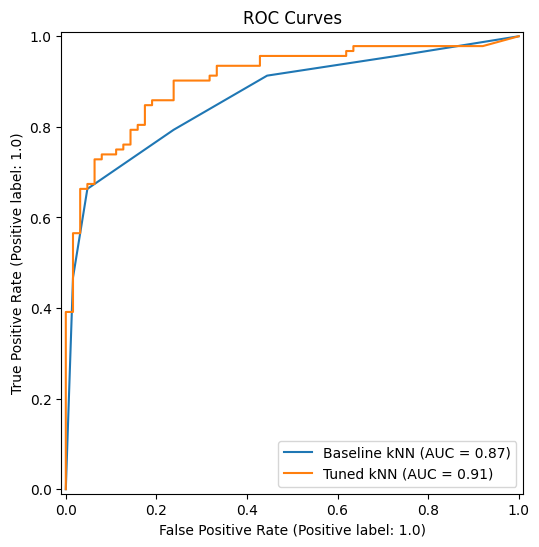

In [70]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,6))

RocCurveDisplay.from_estimator(
    pipe,
    X_test,
    y_test,
    ax=ax,
    name="Baseline kNN"
)

RocCurveDisplay.from_estimator(
    grid_search.best_estimator_,
    X_test,
    y_test,
    ax=ax,
    name="Tuned kNN"
)

plt.title("ROC Curves")
plt.show()

#### Comparing the fined tuned to the base training

In [71]:
from sklearn.metrics import f1_score

best_cv_score = grid_search.best_score_

test_score = f1_score(y_test, y_pred_tuned, average='weighted')

print(f"Best CV score:   {round(best_cv_score, 3)}")
print(f"Test score:      {round(test_score, 3)}")
print(f"Difference:      {round(best_cv_score - test_score, 3)}")
print(f"Overfitting gap: {round((best_cv_score - test_score) * 100, 1)}%")

Best CV score:   0.852
Test score:      0.827
Difference:      0.026
Overfitting gap: 2.6%


##### The difference suggests that the model can generalize well and does not overfit, as the best cv score and test score are similiar.